# MuScaRi: Multi-Scale Species Richness Inference

**MuScaRi** is a scale-aware deep ensemble for predicting vascular plant species richness across Europe. It takes environmental covariates (climate, topography, land cover) and an explicit sampling area as input, and outputs a mean SR estimate together with an uncertainty estimate.

This notebook walks through the full inference pipeline:

1. **Environment setup**: install dependencies (Colab only)
2. **Load model**: pull the pretrained ensemble from Hugging Face
3. **Load features**: stream environmental rasters from the public dataset repo
4. **Predict**: run batched inference at any spatial resolution
5. **Visualise & export**: plot the SR map and write a GeoTIFF

---

### Setup (Colab only)

Run the cell below to clone the repository and install all dependencies into the current Colab runtime. Skip this block if you are running locally with the package already installed.

In [ ]:
# -- Colab setup --
!git clone https://github.com/vboussange/muscari.git
%cd muscari/
!uv sync
!uv pip install torch --torch-backend=auto
!uv pip install -e .

fatal: destination path 'muscari' already exists and is not an empty directory.
Resolved 99 packages in 11ms
Uninstalled 1 package in 0.93ms
 - muscari==0.1.0 (from file:///home/boussang/NNSAR)
Audited 1 package in 4ms
Resolved 94 packages in 167ms                                        
   Building muscari @ file:///home/boussang/NNSAR                      
   Building muscari @ file:///home/boussang/NNSAR              
   Building muscari @ file:///home/boussang/NNSAR              
      Built muscari @ file:///home/boussang/NNSAR              
Prepared 1 package in 549ms                                              
Installed 1 package in 6msm file:///home/boussang/NNSAR)    
 + muscari==0.1.0 (from file:///home/boussang/NNSAR)


> **Restart required.** After installation, restart the runtime (*Runtime → Restart session*) before proceeding, so the freshly installed packages are importable.

In [ ]:
# Navigate to the project root after restarting (Colab only)
%cd muscari/

## Inference utilities

The three helpers below implement the core inference logic:

- `create_features`: aggregates raster data to a target resolution and assembles the feature matrix expected by the model.
- `batch_predict`: runs forward passes in chunks to avoid OOM errors on large grids.
- `create_raster`: packs flat prediction arrays back into a georeferenced `xarray.DataArray`.

In [1]:
from __future__ import annotations

import numpy as np
import pandas as pd
import torch
import xarray as xr
from tqdm import tqdm

from muscari import MuScaRiEnsemble
from muscari.data_processing.utils_features import EnvironmentalFeatureDataset
from muscari.plotting import CMAP_BR


# ---------------------------------------------------------------------------
# Inference helpers
# ---------------------------------------------------------------------------

def create_features(
    model: MuScaRiEnsemble,
    env_dataset: xr.Dataset,
    lc_dataset: xr.Dataset,
    res: float,
) -> pd.DataFrame:
    """Build the feature matrix at a target spatial resolution.

    Parameters
    ----------
    model:
        Pretrained MuScaRi ensemble. Determines which feature columns are required.
    env_dataset:
        Continuous environmental rasters (climate, topography, …) in EPSG:3035.
    lc_dataset:
        Discrete land-cover raster in EPSG:3035.
    res:
        Target cell side length in metres. Rasters are coarsened to this resolution
        by taking the mean (continuous) or class fraction (land cover).

    Returns
    -------
    pd.DataFrame
        Feature matrix with exactly the columns in ``model.feature_names``, indexed
        by (y, x) grid coordinates.
    """
    resolution = abs(env_dataset.rio.resolution()[0])
    ncells = max(1, int(res / resolution))

    # Subset to variables actually used by this model
    env_vars = [
        v for v in env_dataset.data_vars
        if (v in model.feature_names) or (f"std_{v}" in model.feature_names)
    ]
    env_subset = env_dataset[env_vars]
    coarse = env_subset.coarsen(x=ncells, y=ncells, boundary="trim")

    coarse_mean = coarse.mean().rio.write_crs("EPSG:3035")
    coarse_std  = coarse.std().rio.write_crs("EPSG:3035")

    df_mean = coarse_mean.to_dataframe()
    df_std  = coarse_std.to_dataframe().rename(
        columns={c: f"std_{c}" for c in coarse_std.to_dataframe().columns}
    )

    mean_cols = [c for c in df_mean.columns if c in model.feature_names]
    std_cols  = [c for c in df_std.columns  if c in model.feature_names]
    X_map = pd.concat([df_mean[mean_cols], df_std[std_cols]], axis=1)

    # Land-cover class fractions (one column per class)
    lc_frac_cols = sorted(
        [c for c in model.feature_names if c.startswith("lc_frac_")],
        key=lambda c: int(c.split("_")[-1]),
    )
    if lc_frac_cols:
        lc_da = lc_dataset["landcover"].where(lc_dataset["landcover"] >= 0)
        for col in lc_frac_cols:
            idx  = int(col.split("_")[-1])
            frac = (lc_da == idx).coarsen(x=ncells, y=ncells, boundary="trim").mean()
            X_map[col] = frac.to_dataframe(name=col)[col]

    # Log-area is an explicit scale input to MuScaRi
    X_map = X_map.assign(log_sp_unit_area=np.log(res ** 2))
    return X_map[model.feature_names]


def batch_predict(
    model: MuScaRiEnsemble,
    env_dataset: xr.Dataset,
    lc_dataset: xr.Dataset,
    res: float,
    batch_size: int = 2 ** 12,
) -> tuple[pd.DataFrame, np.ndarray, np.ndarray]:
    """Run batched inference across the full grid.

    Parameters
    ----------
    model, env_dataset, lc_dataset, res:
        Passed directly to ``create_features``.
    batch_size:
        Number of grid cells per forward pass. Reduce if GPU memory is limited.

    Returns
    -------
    features: pd.DataFrame
        Feature matrix used for inference.
    mean_SR: np.ndarray, shape (N,)
        Ensemble mean species richness per cell.
    std_SR: np.ndarray, shape (N,)
        Ensemble standard deviation (epistemic uncertainty) per cell.
    """
    features = create_features(model, env_dataset, lc_dataset, res)
    n = len(features)

    mean_SR_parts: list[np.ndarray] = []
    std_SR_parts:  list[np.ndarray] = []

    with torch.no_grad():
        for i in tqdm(range(0, n, batch_size), desc="Predicting SR"):
            X = features.iloc[i : i + batch_size]
            mean_SR_parts.append(model.predict_mean_sr_tot(X))
            std_SR_parts.append(model.get_std_sr_tot(X))

    return features, np.concatenate(mean_SR_parts), np.concatenate(std_SR_parts)


def create_raster(features: pd.DataFrame, values: np.ndarray) -> xr.DataArray:
    """Pack a flat prediction array into a georeferenced DataArray.

    Parameters
    ----------
    features:
        Feature DataFrame whose (y, x) index defines the grid.
    values:
        1-D array of prediction values aligned with ``features``.

    Returns
    -------
    xr.DataArray
        2-D DataArray with CRS EPSG:3035 and ``pred`` as the variable name.
    """
    gdf = features.copy()
    gdf["pred"] = values
    rast = gdf["pred"].to_xarray().sortby(["y", "x"])
    rast = xr.DataArray(
        rast.values,
        dims=["y", "x"],
        coords={"x": rast.x.values, "y": rast.y.values},
        name="pred",
    )
    return rast.rio.write_crs("EPSG:3035")

/Users/victorboussange/projects/MuScaRi/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load model and environmental features

Weights and environmental rasters are streamed automatically from public Hugging Face repositories; no manual downloads required.

| Repository | Contents |
|---|---|
| `vboussange/muscari` | Pretrained ensemble weights |
| `vboussange/muscari-data` | Environmental feature rasters |

In [2]:
MODEL_REPO = "vboussange/muscari"
device = "cuda" if torch.cuda.is_available() else "cpu"

model = MuScaRiEnsemble.from_pretrained(MODEL_REPO)
model.to(device)

print(f"Device : {device}")
print(f"Ensemble size : {model.n_models} members")
print(f"Input features ({len(model.feature_names)}) : {model.feature_names}")

Device : cpu
Ensemble size : 5 members
Input features (11) : ['bio1', 'pet_penman_mean', 'sfcWind_mean', 'bio12', 'std_bio1', 'std_pet_penman_mean', 'std_sfcWind_mean', 'std_bio12', 'elevation', 'std_elevation', 'log_sp_unit_area']


In [3]:
feature_dataset = EnvironmentalFeatureDataset()
env_dataset, lc_dataset = feature_dataset.from_hub(use_cache=False)

env_dataset = env_dataset.rio.write_crs("EPSG:3035")
lc_dataset  = lc_dataset.rio.write_crs("EPSG:3035")

# Drop variables not referenced by this model to reduce memory pressure
env_vars_needed = [
    v for v in env_dataset.data_vars
    if (v in model.feature_names) or (f"std_{v}" in model.feature_names)
]
env_dataset = env_dataset[env_vars_needed]

print(f"Environmental variables ({len(env_vars_needed)}):", env_vars_needed)

Environmental variables (5): ['elevation', 'bio12', 'bio1', 'pet_penman_mean', 'sfcWind_mean']


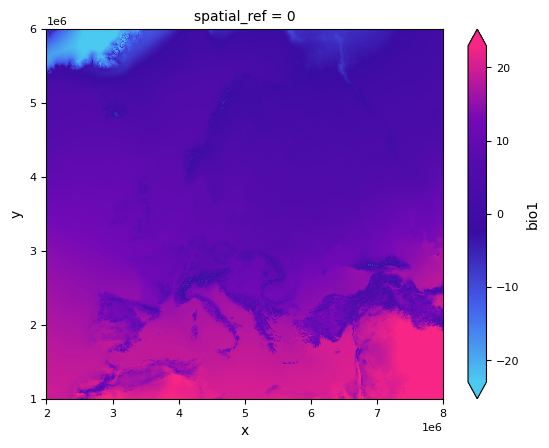

In [4]:
# Quick sanity check: mean annual temperature (bio1) coarsened to ~4× native resolution
env_dataset["bio1"].coarsen(x=4, y=4, boundary="trim").mean().plot(
    cmap=CMAP_BR, robust=True
)

## Predict species richness

MuScaRi is explicitly conditioned on sampling area: the `log_sp_unit_area` feature encodes $\log(A)$ where $A = \text{res}^2$ is the cell area in m².  
Increasing `res` coarsens the spatial grid *and* shifts the scale input, so the model accounts for the species–area relationship automatically.

> **Try it:** change `res` to `10_000` (10 km) or `100_000` (100 km) and re-run to see how predicted richness and spatial patterns respond to scale.

/Users/victorboussange/projects/MuScaRi/.venv/lib/python3.13/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/victorboussange/projects/MuScaRi/.venv/lib/python3.13/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/victorboussange/projects/MuScaRi/.venv/lib/python3.13/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
Predicting SR: 100%|██████████| 3/3 [00:01<00:00,  2.89it/s]


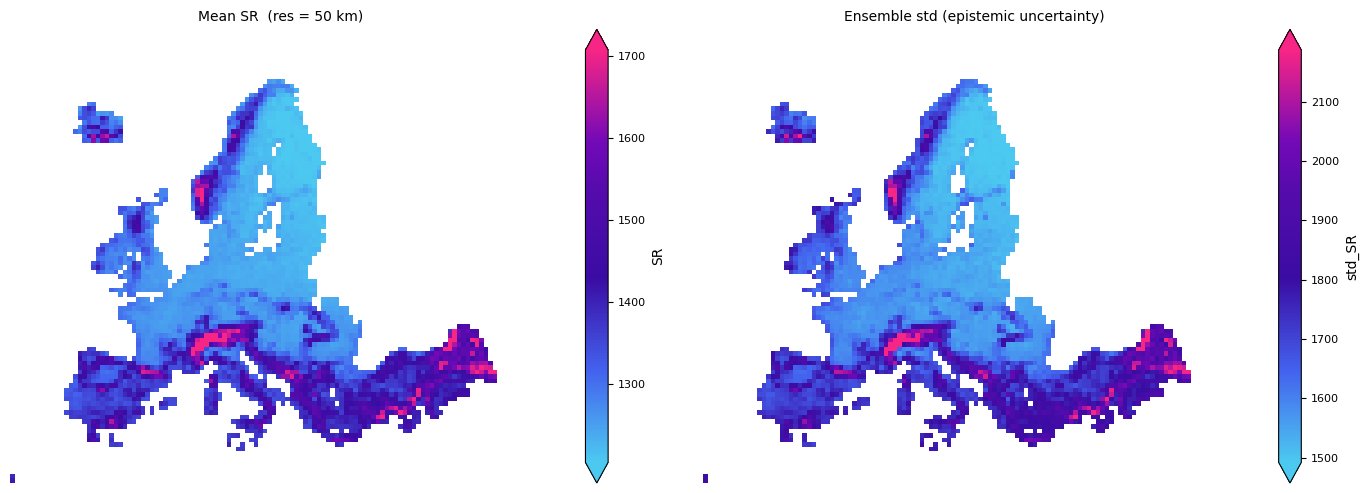

In [5]:
import matplotlib.pyplot as plt

res = 50_000  # cell side length in metres (50 km)

features, SR, std_SR = batch_predict(model, env_dataset, lc_dataset, res)

SR_rast     = create_raster(features, SR).rename("SR")
std_SR_rast = create_raster(features, std_SR).rename("std_SR")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, rast, title in zip(
    axes,
    [SR_rast, std_SR_rast],
    [f"Mean SR  (res = {res/1e3:.0f} km)", "Ensemble std (epistemic uncertainty)"],
):
    rast.plot(
        ax=ax,
        cmap=CMAP_BR,
        vmin=rast.quantile(0.01),
        vmax=rast.quantile(0.99),
        robust=True,
    )
    ax.set_title(title)
    ax.set_axis_off()

fig.tight_layout()

## Export to GeoTIFF

Both the mean SR and the uncertainty estimate are written to cloud-optimised GeoTIFFs. The filenames encode the model slug and the resolution so outputs from different runs don't overwrite each other.

In [6]:
model_slug = MODEL_REPO.split("/")[-1]
suffix = f"{model_slug}_{res:.0f}m.tif"

SR_rast.rio.to_raster(f"SR_mean_{suffix}")
std_SR_rast.rio.to_raster(f"SR_std_{suffix}")

print(f"Saved: SR_mean_{suffix}")
print(f"Saved: SR_std_{suffix}")

Saved: SR_mean_muscari_50000m.tif
Saved: SR_std_muscari_50000m.tif


The GeoTIFFs are now available under the *Files* tab in Colab, or in your local working directory.  
Load them in QGIS, R (`terra`), or Python (`rioxarray`) for further analysis.